In [ ]:
import pandas as pd
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import Normalizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn import preprocessing
from scipy.special import expit
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.nn.modules.loss import _Loss
from torch import Tensor
from sklearn.utils import resample



data = pd.read_csv('.../adult_reconstruction.csv')
data = pd.DataFrame(data)

data['native-country'] = data['native-country'].replace(' ?',np.nan)
data['workclass'] = data['workclass'].replace(' ?',np.nan)
data['occupation'] = data['occupation'].replace(' ?',np.nan)

data = data.drop(['education-num'], axis=1)
data.dropna(how='any',inplace=True)


def bi(input):
  return np.where(input > 50000, 1, 0)


def clip(df, a):
  perm = np.random.permutation(df.index)
  m = len(df.index)
  clip_end = int(a*m)
  cliped = df.iloc[:clip_end]
  return cliped

for col in set(data.columns) - set(data.describe().columns):
  data[col] = data[col].astype('category')

def oneHotCatVars(df, df_cols):

    df_1 = df.drop(columns = df_cols, axis = 1)
    df_2 = pd.get_dummies(df[df_cols])

    return (pd.concat([df_1, df_2], axis=1, join='inner'))

data_preprocessed = oneHotCatVars(data, data.select_dtypes('category').columns)
#data_preprocessed = clip(data_preprocessed, 0.1)

normalize_columns = ['age', 'capital-gain', 'capital-loss', 'hours-per-week']

def normalize(columns):
  scaler = preprocessing.StandardScaler()
  data_preprocessed[columns] = scaler.fit_transform(data_preprocessed[columns])


normalize(normalize_columns)

data_w = data_preprocessed[data_preprocessed['race_White'] == 1]
data_b = data_preprocessed[data_preprocessed['race_Black'] == 1]

data_preprocessed = pd.concat([data_w, data_b])

x_train, x_test = train_test_split(data_preprocessed)



train_x = x_train.drop(['income'],axis=1)
train_x = train_x.drop(['race_White'],axis=1)
train_x = train_x.drop(['race_Black'],axis=1)
train_label = bi(x_train['income'].to_numpy())
train_sen = x_train['race_Black'].to_numpy()
test_x = x_test.drop(['income'],axis=1)
test_x = test_x.drop(['race_White'],axis=1)
test_x = test_x.drop(['race_Black'],axis=1)
test_label = bi(x_test['income'].to_numpy())
test_sen = x_test['race_Black'].to_numpy()

class ShelterOutcomeDataset(Dataset):
    def __init__(self, X, Y, A):
        self.x = X.to_numpy().astype(np.float32)
        self.y = Y
        self.a =  A

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx], self.a[idx]

In [ ]:
def pgd_attack(model, images, labels, eps, alpha=2/255, iters=40):
    loss = nn.CrossEntropyLoss()

    ori_images = images.data

    for i in range(iters) :
        images.requires_grad = True
        outputs = model(images)

        model.zero_grad()
        cost = loss(outputs, labels)
        cost.backward()

        adv_images = images + alpha*images.grad.sign()
        eta = torch.clamp(adv_images - ori_images, min=-eps, max=eps)
        images = torch.clamp(ori_images + eta, min=0, max=1).detach_()

    return images

class Classifier_complx(nn.Module):
    def __init__(self, input_size = 104, hidden_size = 512):
        super(Classifier_complx, self).__init__()

        self.dense1 = nn.Linear(input_size, hidden_size)
        self.dense2 = nn.Linear(hidden_size, hidden_size)
        self.dense4 = nn.Linear(hidden_size, 2)
        #self.dense5 = nn.Linear(2, 2)

    def forward(self, x):
        x = F.relu(self.dense1(x))
        x = F.relu(self.dense2(x))
        x = self.dense4(x)
        #x = self.dense5(x)

        return F.log_softmax(x,-1)


train_ds = ShelterOutcomeDataset(train_x, train_label, train_sen)
#train_ds_ro = ShelterDataset(examples, labels, sens_atr)
test_ds = ShelterOutcomeDataset(test_x, test_label, test_sen)
con = 0.4
eps = 0.1



batch_size_train, batch_size_test = 128, test_x.shape[0]
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=batch_size_train, shuffle=True)
#train_loader_ro = torch.utils.data.DataLoader(train_ds_ro, batch_size=batch_size_train, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=batch_size_test, shuffle=False)


classifier = Classifier_complx()
optimizer = optim.SGD(classifier.parameters(), lr=0.01, momentum=0.8)


def train(epoch):

  classifier.train()

  for batch_idx, (x, y, a) in enumerate(train_loader):
    x.requires_grad = True
    optimizer.zero_grad()
    idx_bp = np.where(np.logical_and(a==1,y==1))
    idx_wp = np.where(np.logical_and(a==0,y==1))
    idx_bn = np.where(np.logical_and(a==1,y==0))
    idx_wn = np.where(np.logical_and(a==0,y==0))
    output = classifier(x)
    p1 = torch.squeeze(output[[idx_bp]],0) / len(np.array(idx_bp))
    p2 = torch.squeeze(output[[idx_wp]],0) / len(np.array(idx_wp))
    p3 = torch.squeeze(output[[idx_bn]],0) / len(np.array(idx_bn))
    p4 = torch.squeeze(output[[idx_wn]],0) / len(np.array(idx_wn))
    bp = output[idx_bp]
    wp = output[idx_wp]
    bn = output[idx_bn]
    wn = output[idx_wn]
    eod = abs(torch.sum(torch.exp(bn)[:,0]) / len(np.array(idx_bn)[0]) - torch.sum(torch.exp(wn)[:,0]) / len(np.array(idx_wn)[0])) + abs(torch.sum(torch.exp(bp)[:,1]) / len(np.array(idx_bp)[0]) - torch.sum(torch.exp(wp)[:,1]) / len(np.array(idx_wp)[0]))
    loss = F.nll_loss(output, y)
    x_adv = pgd_attack(classifier, x, y, eps)
    output_adv  = classifier(x_adv)
    bp_adv = output_adv[idx_bp] / len(np.array(idx_bp))
    wp_adv = output_adv[idx_wp] / len(np.array(idx_wp))
    bn_adv = output_adv[idx_bn] / len(np.array(idx_bn))
    wn_adv = output_adv[idx_wn] / len(np.array(idx_wn))
    eod_adv = abs(torch.sum(torch.exp(bn_adv)[:,0]) / len(np.array(idx_bn)[0]) - torch.sum(torch.exp(wn_adv)[:,0]) / len(np.array(idx_wn)[0])) + abs(torch.sum(torch.exp(bp_adv)[:,1]) / len(np.array(idx_bp)[0]) - torch.sum(torch.exp(wp_adv)[:,1]) / len(np.array(idx_wp)[0]))
    loss_adv = F.nll_loss(classifier(x_adv), y) + con * eod_adv

    loss_adv.backward()
    #loss.backward()
    optimizer.step()

    if batch_idx % 10 == 0:
      train_losses.append(loss_adv.item())
      train_counter.append(
        (batch_idx*128) + ((epoch-1)*len(train_loader.dataset)))
    if batch_idx % 20 == 0:
      print(f'Epoch {epoch}: [{batch_idx*len(x)}/{len(train_loader.dataset)}] Loss: {loss_adv.item()}')



def test(epoch):

  classifier.eval()
  test_loss = 0
  correct = 0

  with torch.no_grad():
    for x, y, a in test_loader:
      y = y.long()
      output = classifier(x)
      test_loss += F.nll_loss(output, y).item()
      pred = output.data.max(1, keepdim=True)[1]
      correct += pred.eq(y.data.view_as(pred)).sum()
  test_losses.append(test_loss)
  test_counter.append(len(train_loader.dataset)*epoch)

  print(f'Test result of FC on epoch {epoch}: Avg loss is {test_loss}, Accuracy: {100.*correct/len(test_loader.dataset)}%')

train_losses = []
train_counter = []
test_losses = []
test_counter = []
max_epoch = 100

for epoch in range(1, max_epoch+1):
  train(epoch)
  test(epoch)

def model_eval(actual, pred):

    confusion = pd.crosstab(actual, pred, rownames=['Actual'], colnames=['Predicted'])
    TP = confusion.loc[1,1] + 1
    TN = confusion.loc[0,0] + 1
    FP = confusion.loc[0,1] + 1
    FN = confusion.loc[1,0] + 1

    out = {}
    out['ALL'] = (TP+TN+FP+FN-4)
    out['DP'] = (TP+FP-2)/(TP+TN+FP+FN-4)
    out['TPR'] =  (TP-1)/(TP+FN-2)
    out['TNR'] = (TN-1)/(FP+TN-2)
    out['FPR'] = (FP-1)/(FP+TN-2)
    out['FNR'] = (FN-1)/(TP+FN-2)
    out['ACR'] = (TP+TN-2)/(TP+TN+FP+FN-4)

    return out

for x, y, a in test_loader:
      y = y.long()
      output = classifier(x)
      idx_b = np.where(a==1)
      y_b = y[[idx_b]]
      pred_b = output[[idx_b]]
      pred_b = torch.squeeze(pred_b,0).data.max(1, keepdim=True)[1]
      idx_w = np.where(a==0)
      y_w = y[[idx_w]]
      pred_w = output[[idx_w]]
      pred_w = torch.squeeze(pred_w,0).data.max(1, keepdim=True)[1]


w = model_eval(torch.squeeze(y_w,0), pred_w.detach().numpy().reshape(pred_w.shape[0]))
b = model_eval(torch.squeeze(y_b,0), pred_b.detach().numpy().reshape(pred_b.shape[0]))



DI1 = 100 * abs(w['DP'] - b['DP'])
DFPR1 = 100 * abs(w['TNR'] - b['TNR'])
DFNR1 = 100 * abs(w['TPR'] - b['TPR'])
w_TNR  = 100 * w['TNR']
w_TPR  = 100 * w['TPR']
b_TNR  = 100 * b['TNR']
b_TPR  = 100 * b['TPR']


print(f'Race: disparate impact is {DI1}%, eod is {DFPR1+DFNR1}%.')

In [ ]:
def model_eval(actual, pred):

    confusion = pd.crosstab(actual, pred, rownames=['Actual'], colnames=['Predicted'])
    try:
      TP = confusion.loc[1,1] + 1
    except KeyError:
      TP = 1
    try:
      TN = confusion.loc[0,0] + 1
    except KeyError:
      TN = 1
    try:
      FP = confusion.loc[0,1] + 1
    except KeyError:
      FP = 1
    try:
      FN = confusion.loc[1,0] + 1
    except KeyError:
      FN = 1


    out = {}
    out['ALL'] = (TP+TN+FP+FN-4)
    out['DP'] = (TP+FP-2)/(TP+TN+FP+FN-4)
    out['TPR'] =  (TP-1)/(TP+FN-2)
    out['TNR'] = (TN-1)/(FP+TN-2)
    out['FPR'] = (FP-1)/(FP+TN-2)
    out['FNR'] = (FN-1)/(TP+FN-2)
    out['ACR'] = (TP+TN-2)/(TP+TN+FP+FN-4)

    return out

def test(model, test_loader, epsilon):

    # Accuracy counter
    correct = 0
    adv_examples = []
    model.eval()

    # Loop over all examples in test set
    for data, target, sen in test_loader:


        # Set requires_grad attribute of tensor. Important for Attack
        data.requires_grad = True

        # Forward pass the data through the model
        idx_b = np.where(sen==1)
        idx_w = np.where(sen==0)
        idx_bp = np.where(np.logical_and(sen==1,target==1))
        idx_wp = np.where(np.logical_and(sen==0,target==1))
        idx_bn = np.where(np.logical_and(sen==1,target==0))
        idx_wn = np.where(np.logical_and(sen==0,target==0))
        output = model(data)
        init_pred = torch.squeeze(output.max(1, keepdim=True)[1],1) # get the index of the max log-probability

        # If the initial prediction is wrong, dont bother attacking, just move on
        for i in range(len(init_pred)):
          if init_pred[i].item() != target[i].item():
              continue

        # Calculate the loss
        p1 = torch.squeeze(output[[idx_bp]],0)
        p2 = torch.squeeze(output[[idx_wp]],0)
        p3 = torch.squeeze(output[[idx_bn]],0)
        p4 = torch.squeeze(output[[idx_wn]],0)
        p5 = torch.squeeze(output[[idx_b]],0)
        p6 = torch.squeeze(output[[idx_w]],0)
        loss = F.nll_loss(output, target)
        #loss = abs(torch.sum(torch.exp(p3)[:,0]) / len(np.array(idx_bn)[0]) - torch.sum(torch.exp(p4)[:,0]) / len(np.array(idx_wn)[0])) + abs(torch.sum(torch.exp(p2)[:,1]) / len(np.array(idx_wp)[0]) - torch.sum(torch.exp(p1)[:,1]) / len(np.array(idx_bp)[0]))
        # Zero all existing gradients
        model.zero_grad()

        # Calculate gradients of model in backward pass
        loss.backward()

        # Collect datagrad
        data_grad = data.grad.data

        # Call FGSM Attack
        perturbed_data = pgd_attack(model, data, target, epsilon)

        # Re-classify the perturbed image
        output = model(perturbed_data)

        # Check for success
        final_pred = output.max(1, keepdim=True)[1] # get the index of the max log-probability
        y_b = target[[idx_b]]
        pred_b = output[[idx_b]]
        pred_b = torch.squeeze(pred_b,0).data.max(1, keepdim=True)[1]
        y_w = target[[idx_w]]
        pred_w = output[[idx_w]]
        pred_w = torch.squeeze(pred_w,0).data.max(1, keepdim=True)[1]
        w = model_eval(torch.squeeze(y_w,0), pred_w.detach().numpy().reshape(pred_w.shape[0]))
        b = model_eval(torch.squeeze(y_b,0), pred_b.detach().numpy().reshape(pred_b.shape[0]))
        DI1 = 100 * abs(w['DP'] - b['DP'])
        DFPR1 = 100 * abs(w['TNR'] - b['TNR'])
        DFNR1 = 100 * abs(w['TPR'] - b['TPR'])
        w_TNR  = 100 * w['TNR']
        w_TPR  = 100 * w['TPR']
        b_TNR  = 100 * b['TNR']
        b_TPR  = 100 * b['TPR']
        DI1 = 100 * abs(w['DP'] - b['DP'])
        DFPR1 = 100 * abs(w['TNR'] - b['TNR'])
        DFNR1 = 100 * abs(w['TPR'] - b['TPR'])
        for i in range(len(final_pred)):
          if final_pred[i].item() == target[i].item():
              correct += 1
              # Special case for saving 0 epsilon examples
              if (epsilon == 0) and (len(adv_examples) < 5):
                  adv_ex = perturbed_data[i].squeeze().detach().cpu().numpy()
                  adv_examples.append( (init_pred[i].item(), final_pred[i].item(), adv_ex) )
          else:
              # Save some adv examples for visualization later
              if len(adv_examples) < 5:
                  adv_ex = perturbed_data[i].squeeze().detach().cpu().numpy()
                  adv_examples.append( (init_pred[i].item(), final_pred[i].item(), adv_ex) )

    # Calculate final accuracy for this epsilon
    final_acc = correct/data.shape[0]
    print("Epsilon: {}\tTest Accuracy = {} / {} = {}\tDisparate impact = {}%\tEod = {}%.')".format(epsilon, correct, data.shape[0], final_acc, DI1, DFPR1+DFNR1))

    # Return the accuracy and an adversarial example
    return DI1, DFPR1+DFNR1, final_acc, adv_examples, final_pred, w_TNR, w_TPR, b_TNR, b_TPR

In [ ]:
accuracies = []
examples = []
DI = []
EOd = []
w_tpr = []
w_tnr = []
b_tpr = []
b_tnr = []
epsilons = [0, .05, .1, .15, .2, .25, .3, .35, .4, .45, .5]

# Run test for each epsilon
for eps in epsilons:
    di, eod, acc, ex, fp, w1, w2, b1, b2 = test(classifier, test_loader, eps)
    accuracies.append(acc)
    examples.append(ex)
    DI.append(di / 100)
    EOd.append(eod / 100)
    w_tnr.append(w1 / 100)
    w_tpr.append(w2 / 100)
    b_tnr.append(b1 / 100)
    b_tpr.append(b2 / 100)

Epsilon: 0	Test Accuracy = 9940 / 11784 = 0.8435166327223353	Disparate impact = 14.079293329954945%	Eod = 25.149146055256%.')
Epsilon: 0.05	Test Accuracy = 7782 / 11784 = 0.6603869653767821	Disparate impact = 12.26869156339423%	Eod = 24.06611743930766%.')
Epsilon: 0.1	Test Accuracy = 5698 / 11784 = 0.4835369993211134	Disparate impact = 10.175524405072057%	Eod = 19.167113656556936%.')
Epsilon: 0.15	Test Accuracy = 3592 / 11784 = 0.3048200950441276	Disparate impact = 6.545839497922268%	Eod = 17.711213308825098%.')
Epsilon: 0.2	Test Accuracy = 1320 / 11784 = 0.1120162932790224	Disparate impact = 8.02993287703323%	Eod = 4.400731870749469%.')
Epsilon: 0.25	Test Accuracy = 79 / 11784 = 0.0067040054310930075	Disparate impact = 14.075281427596643%	Eod = 0.3302334614488919%.')
Epsilon: 0.3	Test Accuracy = 0 / 11784 = 0.0	Disparate impact = 13.910025368132894%	Eod = 0.0%.')
Epsilon: 0.35	Test Accuracy = 0 / 11784 = 0.0	Disparate impact = 13.910025368132894%	Eod = 0.0%.')
Epsilon: 0.4	Test Accura

In [ ]:
accuracies_adv1 = []
examples1 = []
DI_adv1 = []
EOd_adv1 = []
w_tpr_adv1 = []
w_tnr_adv1 = []
b_tpr_adv1 = []
b_tnr_adv1 = []
epsilons = [0, .05, .1, .15, .2, .25, .3, .35, .4, .45, .5]

# Run test for each epsilon
for eps in epsilons:
    di, eod, acc, ex, fp, w1, w2, b1, b2 = test(classifier, test_loader, eps)
    accuracies_adv1.append(acc)
    examples1.append(ex)
    DI_adv1.append(di / 100)
    EOd_adv1.append(eod / 100)
    w_tnr_adv1.append(w1 / 100)
    w_tpr_adv1.append(w2 / 100)
    b_tnr_adv1.append(b1 / 100)
    b_tpr_adv1.append(b2 / 100)

Epsilon: 0	Test Accuracy = 9744 / 11784 = 0.8268839103869654	Disparate impact = 7.802921981051633%	Eod = 8.718542659457123%.')
Epsilon: 0.05	Test Accuracy = 9514 / 11784 = 0.8073659198913782	Disparate impact = 7.13156088438757%	Eod = 8.28876197565585%.')
Epsilon: 0.1	Test Accuracy = 9280 / 11784 = 0.7875084860828242	Disparate impact = 7.420661252692177%	Eod = 7.697749130113607%.')
Epsilon: 0.15	Test Accuracy = 8795 / 11784 = 0.7463509843856077	Disparate impact = 6.26554778585182%	Eod = 5.77377750096412%.')
Epsilon: 0.2	Test Accuracy = 8408 / 11784 = 0.7135098438560761	Disparate impact = 6.510513555859532%	Eod = 8.270585518212952%.')
Epsilon: 0.25	Test Accuracy = 7739 / 11784 = 0.6567379497623896	Disparate impact = 6.33451319065266%	Eod = 9.368103530489446%.')
Epsilon: 0.3	Test Accuracy = 7370 / 11784 = 0.6254243041412084	Disparate impact = 5.591333510502144%	Eod = 9.441619983127532%.')
Epsilon: 0.35	Test Accuracy = 7087 / 11784 = 0.6014086897488119	Disparate impact = 6.324567824948519%

In [ ]:
accuracies_adv = []
examples = []
DI_adv = []
EOd_adv = []
w_tpr_adv = []
w_tnr_adv = []
b_tpr_adv = []
b_tnr_adv = []
epsilons = [0, .05, .1, .15, .2, .25, .3, .35, .4, .45, .5]

# Run test for each epsilon
for eps in epsilons:
    di, eod, acc, ex, fp, w1, w2, b1, b2 = test(classifier, test_loader, eps)
    accuracies_adv.append(acc)
    examples.append(ex)
    DI_adv.append(di / 100)
    EOd_adv.append(eod / 100)
    w_tnr_adv.append(w1 / 100)
    w_tpr_adv.append(w2 / 100)
    b_tnr_adv.append(b1 / 100)
    b_tpr_adv.append(b2 / 100)

Epsilon: 0	Test Accuracy = 9903 / 11784 = 0.8403767820773931	Disparate impact = 12.066241655590357%	Eod = 18.77290112604002%.')
Epsilon: 0.05	Test Accuracy = 9512 / 11784 = 0.8071961982348947	Disparate impact = 11.65870264555954%	Eod = 21.585796262722333%.')
Epsilon: 0.1	Test Accuracy = 9190 / 11784 = 0.7798710115410726	Disparate impact = 11.757227123434145%	Eod = 22.446514457451762%.')
Epsilon: 0.15	Test Accuracy = 7734 / 11784 = 0.6563136456211812	Disparate impact = 12.387806660297192%	Eod = 21.82036649107959%.')
Epsilon: 0.2	Test Accuracy = 6288 / 11784 = 0.5336048879837068	Disparate impact = 10.22969734323001%	Eod = 17.885703347276646%.')
Epsilon: 0.25	Test Accuracy = 5686 / 11784 = 0.48251866938221316	Disparate impact = 9.224303173006223%	Eod = 18.933665802514813%.')
Epsilon: 0.3	Test Accuracy = 5098 / 11784 = 0.43262050237610317	Disparate impact = 7.429373155372643%	Eod = 16.11396964752616%.')
Epsilon: 0.35	Test Accuracy = 4853 / 11784 = 0.4118295994568907	Disparate impact = 6.68

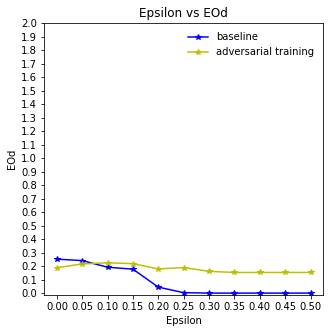

In [ ]:
plt.figure(figsize=(5,5))
plt.plot(epsilons, EOd, label='baseline', color='b', marker='*')
plt.plot(epsilons, EOd_adv, label='adversarial training', color='y', marker='*')
#plt.plot(epsilons, DI_post2, label='epsilon=0.2', color='r', marker='*')
#plt.plot(epsilons, accuracies_pre, label='adversarial training (preprocessing)', color='c', marker='*')
plt.yticks(np.arange(0, 2.1, step=0.1))
plt.xticks(np.arange(0, .55, step=0.05))
plt.title("Epsilon vs EOd")
plt.xlabel("Epsilon")
plt.ylabel("EOd")
plt.legend(frameon=False, loc = 'best')
plt.show()

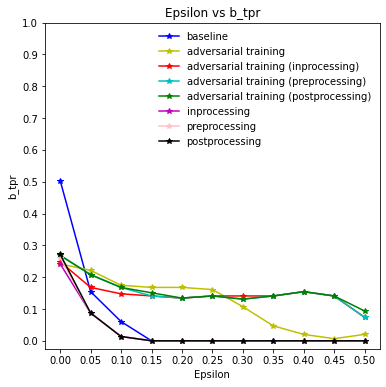

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,6))
plt.plot(epsilons, b_tpr, label='baseline', color='b', marker='*')
plt.plot(epsilons, b_tpr_adv, label='adversarial training', color='y', marker='*')
plt.plot(epsilons, b_tpr_advf, label='adversarial training (inprocessing)', color='r', marker='*')
plt.plot(epsilons, b_tpr_advf_pre, label='adversarial training (preprocessing)', color='c', marker='*')
plt.plot(epsilons, b_tpr_advf_post, label='adversarial training (postprocessing)', color='g', marker='*')
plt.plot(epsilons, b_tpr_f, label='inprocessing', color='m', marker='*')
plt.plot(epsilons, b_tpr_f_pre, label='preprocessing', color='pink', marker='*')
plt.plot(epsilons, b_tpr_f_post, label='postprocessing', color='k', marker='*')
plt.yticks(np.arange(0, 1.1, step=0.1))
plt.xticks(np.arange(0, .55, step=0.05))
plt.title("Epsilon vs b_tpr")
plt.xlabel("Epsilon")
plt.ylabel("b_tpr")
plt.legend(frameon=False, loc = 'best')
plt.show()